In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import os

# Extract Data

In [2]:
OUTPUT_DIR = os.path.join("..", "outputs")

all_points = pd.read_csv(os.path.join(OUTPUT_DIR, "all_peaks_lost.csv"))
families = pd.read_csv(os.path.join(OUTPUT_DIR, "families_lost.csv"))

families

,family_id,act_RF_mW,mu,sigma
0,0,20.022043,52.530485,0.500000
1,0,19.110590,51.732382,0.746414
2,0,17.894697,50.878484,0.500000
3,0,17.205557,54.537678,0.760209
4,0,16.125294,53.385259,0.500000
...,...,...,...,...
103,7,11.734339,101.407707,0.726243
104,7,11.378540,101.078974,1.388329
105,7,11.092823,102.781765,0.569473
106,7,10.790574,102.450948,0.905387


In [3]:
power_rf1 = families[families['family_id'] == 1]['act_RF_mW'].values
omega1 = families[families['family_id'] == 1]['mu'].values
sigma1 = families[families['family_id'] == 1]['sigma'].values

power_rf2 = families[families['family_id'] == 2]['act_RF_mW'].values
omega2 = families[families['family_id'] == 2]['mu'].values
sigma2 = families[families['family_id'] == 2]['sigma'].values

# Perform Fitting

In [4]:
def fit_sqrt(x, a, b):
    return a * np.sqrt(x - b)

In [5]:
p0_1 = [20.6, 2.73]
p0_2 = [20.6, 2.73]
bounds_1 = ([0, 0], [np.inf, np.inf])
bounds_2 = ([0, 0], [np.inf, np.inf])

popt_1, _ = curve_fit(fit_sqrt, power_rf1, omega1, p0=p0_1, bounds=bounds_1)
popt_2, _ = curve_fit(fit_sqrt, power_rf2, omega2, p0=p0_2, bounds=bounds_2)

# Generate Figure

In [6]:
x_fit_1 = np.linspace(np.min(power_rf1), np.max(power_rf1), 200)
y_fit_1 = fit_sqrt(x_fit_1, *popt_1)

x_fit_2 = np.linspace(np.min(power_rf2), np.max(power_rf2), 200)
y_fit_2 = fit_sqrt(x_fit_2, *popt_2)

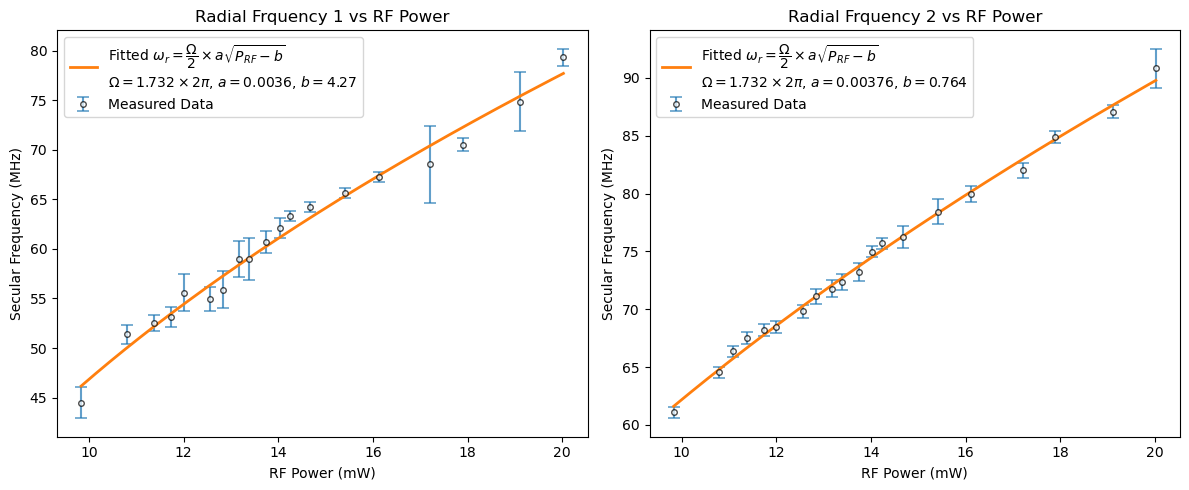

In [18]:
Omega = 1.732 * 2 * np.pi * 1e3  # MHz

a1 = 2 * popt_1[0] / Omega
b1 = popt_1[1]
a2 = 2 * popt_2[0] / Omega
b2 = popt_2[1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(
    power_rf1,
    omega1,
    yerr=sigma1,
    fmt='o',
    elinewidth=1.5,
    capsize=4,
    capthick=1.2,
    markersize=4,
    markerfacecolor='w',
    markeredgecolor='k',
    alpha=0.7,
    label='Measured Data'
)
ax1.plot(
    x_fit_1,
    y_fit_1,
    '-',
    lw=2,
    label=rf'Fitted $\omega_{{r}} = \dfrac{{\Omega}}{{2}} \times a\sqrt{{P_{{RF}}-b}}$''\n'
          rf'$\Omega = 1.732 \times 2\pi$, $a={a1:.3g}$, $b={b1:.3g}$'
)
ax1.set_xlabel('RF Power (mW)')
ax1.set_ylabel('Secular Frequency (MHz)')
ax1.set_title("Radial Frquency 1 vs RF Power")
#ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.errorbar(
    power_rf2,
    omega2,
    yerr=sigma2,
    fmt='o',
    elinewidth=1.5,
    capsize=4,
    capthick=1.2,
    markersize=4,
    markerfacecolor='w',
    markeredgecolor='k',
    alpha=0.7,
    label='Measured Data'
)
ax2.plot(
    x_fit_2, y_fit_2, '-', lw=2,
    label=rf'Fitted $\omega_{{r}} = \dfrac{{\Omega}}{{2}} \times a\sqrt{{P_{{RF}}-b}}$''\n'
          rf'$\Omega = 1.732 \times 2\pi$, $a={a2:.3g}$, $b={b2:.3g}$'
)
ax2.set_xlabel('RF Power (mW)')
ax2.set_ylabel('Secular Frequency (MHz)')
ax2.set_title("Radial Frquency 2 vs RF Power")
#ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()
